# Cascaded MZI Filter

This example shows how to assemble components together to form a complex component that can be simulated by integrating `gdsfactory`, `tidy3d`, and `sax`.  The design is based on the first stage of the Coarse Wavelength Division Multiplexer presented in [S. Dwivedi, P. De Heyn, P. Absil, J. Van Campenhout and W. Bogaerts, “Coarse wavelength division multiplexer on silicon-on-insulator for 100 GbE,” _2015 IEEE 12th International Conference on Group IV Photonics (GFP)_, Vancouver, BC, Canada, 2015, pp. 9-10, doi: 10.1109/Group4.2015.7305928.](https://doi.org/10.1109/Group4.2015.7305928)

Each filter stage is formed by 4 cascaded Mach-Zenhder Interferometers (MZIs) with predefined delays for the central wavelength.  Symmetrical Direction Couplers (DCs) are used to mix the signals at the ends of the MZI arms.  In order to facilitate fabrication, all DC gaps are kept equal, so the power transfer ratios are defined by the coupling length of the DCs.

We will design each DC through 3D FDTD simulations to guarantee the desired power ratios, which have been calculated to provide maximally flat response.  The S parameters computed through FDTD are latter used in the full circuit simulation along with models for staight and curved waveguide sections, leading to an accurate model that exhibits features similar to those found in experimental data.

In [1]:
import gdsfactory as gf
import gdsfactory.simulation.gtidy3d as gt

import tidy3d as td

import jax
import jax.numpy as jnp

import sax

import numpy as np

import matplotlib.pyplot as plt

2023-02-21 21:42:04.586 | INFO     | gdsfactory.config:<module>:50 - Load '/home/lucas/Flexcompute/dev/gdsfactory/gdsfactory' 6.43.1


[21:42:06] WARNING  This version of Tidy3D was pip installed from the 'tidy3d-beta' repository on   ]8;id=952690;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/__init__.py\__init__.py]8;;\:]8;id=26311;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/__init__.py#102\102]8;;\
                    PyPI. Future releases will be uploaded to the 'tidy3d' repository. From now on,                
                    please use 'pip install tidy3d' instead.                                                       

           INFO     Using client version: 1.8.4                                                     ]8;id=380563;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/__init__.py\__init__.py]8;;\:]8;id=52233;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/__init__.py#120\120]8;;\

2023-02-21 21:42:07.110 | INFO     | gdsfactory.simulation.gtidy3d:<module>:54 - Tidy3d '1.8.4' installed at ['/home/lucas/Flexcompute/dev/tidy3d/tidy3d']


[21:42:07] INFO     Generating grammar tables from                                <frozen importlib._bootstrap>:241
                    /home/lucas/.venv/flexcompute/lib/python3.10/site-packages/bl                                  
                    ib2to3/Grammar.txt                                                                             

           INFO     Writing grammar tables to                                     <frozen importlib._bootstrap>:241
                    /home/lucas/.cache/black/22.3.0/Grammar3.10.9.final.0.pickle                                   

           INFO     Writing failed: [Errno 2] No such file or directory:          <frozen importlib._bootstrap>:241
                    '/home/lucas/.cache/black/22.3.0/tmp1gkgdr85'                                                  

           INFO     Generating grammar tables from                                <frozen importlib._bootstrap>:241
                    /home/lucas/.venv/flexcompute/lib/python3.10/site-packages/bl                                  
                    ib2to3/PatternGrammar.txt                                                                      

           INFO     Writing grammar tables to                                     <frozen importlib._bootstrap>:241
                    /home/lucas/.cache/black/22.3.0/PatternGrammar3.10.9.final.0.                                  
                    pickle                                                                                         

           INFO     Writing failed: [Errno 2] No such file or directory:          <frozen importlib._bootstrap>:241
                    '/home/lucas/.cache/black/22.3.0/tmpp9tfp_kc'                                                  

We start by loading the desired PDK and setting the main geometry and filter parameters, such as DC gap and central wavelength.

In [2]:
fsr = 0.01
gap = 0.15
width = 0.45
wavelengths = np.linspace(1.5, 1.6, 101)
lda_c = wavelengths[wavelengths.size // 2]

pdk = gf.get_active_pdk()

cross_section = pdk.get_cross_section("strip", width=width)

layer_stack = pdk.get_layer_stack()
core = layer_stack.layers["core"]
clad = layer_stack.layers["clad"]
box = layer_stack.layers["box"]

print(f"""Stack:
- {clad.material} clad with {clad.thickness}µm
- {core.material} clad with {core.thickness}µm
- {box.material} clad with {box.thickness}µm""")

2023-02-21 21:42:07.693 | WARNING  | gdsfactory.pdk:get_active_pdk:556 - No active PDK.
Activating the generic PDK
import gdsfactory as gf 
PDK = gf.get_generic_pdk()
PDK.activate()
2023-02-21 21:42:07.832 | INFO     | gdsfactory.technology.layer_views:__init__:785 - Importing LayerViews from YAML file: /home/lucas/Flexcompute/dev/gdsfactory/gdsfactory/generic_tech/layer_views.yaml.
2023-02-21 21:42:07.842 | INFO     | gdsfactory.pdk:activate:206 - 'generic' PDK is now active


Stack:
- sio2 clad with 3.0µm
- si clad with 0.22µm
- sio2 clad with 3.0µm


The first component we need to design is the DC.  We model the coupling reagion first:

In [3]:
@gf.cell
def coupler_straight(gap: float, length: float, cross_section: gf.types.CrossSectionSpec = "strip") -> gf.Component:
    cs = gf.get_cross_section(cross_section)
    Δy = (cs.width + gap) / 2
    
    sc = gf.components.straight(length, cross_section=cross_section)

    c = gf.Component()
    arm0 = c.add_ref(sc).movey(Δy)
    arm1 = c.add_ref(sc).movey(-Δy)
            
    c.add_port(name="o1", port=arm1.ports["o1"])
    c.add_port(name="o2", port=arm0.ports["o1"])
    c.add_port(name="o3", port=arm0.ports["o2"])
    c.add_port(name="o4", port=arm1.ports["o2"])

    return c


coupler_straight(gap, 2.0, cross_section=cross_section)

/home/lucas/Flexcompute/dev/gdsfactory/gdsfactory/__init__.py:83: UserWarning: gdsfactory.types has been renamed to gdsfactory.typings
  warn("gdsfactory.types has been renamed to gdsfactory.typings")


AppLayout(children=(Tab(children=(VBox(children=(HBox(children=(Button(layout=Layout(border_bottom='solid 2px …

coupler_straight_855790a7: uid 122ab933, ports ['o1', 'o2', 'o3', 'o4'], references ['straight_1', 'straight_2'], 0 polygons


Next, we design the waveguide separating region using S bends.

In [4]:
@gf.cell
def coupler_splitter(gap: float, separation: float = 4.0, bend_factor: float = 3.0, cross_section: gf.types.CrossSectionSpec = "strip") -> gf.Component:
    cs = gf.get_cross_section(cross_section)
    Δy = (cs.width + gap) / 2
    Δx = (separation / 2 - Δy) * bend_factor
    assert Δy < separation / 2
    
    sc = gf.components.bend_s((Δx, separation / 2 - Δy), 199, cross_section=cross_section)

    c = gf.Component()
    arm0 = c.add_ref(sc).movey(Δy)
    arm1 = c.add_ref(sc).movey(Δy).mirror((0, 0), (1, 0))
    
    c.add_port(name="o1", port=arm1.ports["o1"])
    c.add_port(name="o2", port=arm0.ports["o1"])
    c.add_port(name="o3", port=arm0.ports["o2"])
    c.add_port(name="o4", port=arm1.ports["o2"])

    return c

separation = 2.0
bend_factor = 4.0

coupler_splitter(gap, separation=separation, bend_factor=bend_factor, cross_section=cross_section)

AppLayout(children=(Tab(children=(VBox(children=(HBox(children=(Button(layout=Layout(border_bottom='solid 2px …

coupler_splitter_7c06c0f4: uid fcec1d21, ports ['o1', 'o2', 'o3', 'o4'], references ['bend_s_1', 'bend_s_2'], 0 polygons


To complete the DC, we join teh previos designs in a full component.

In [5]:
@gf.cell
def coupler_symmetric(gap: float, length: float, separation: float = 4.0, bend_factor: float = 3.0, cross_section: gf.types.CrossSectionSpec = "strip") -> gf.Component:
    splitter = coupler_splitter(gap, separation=separation, bend_factor=bend_factor, cross_section=cross_section)
    straight = coupler_straight(gap, length, cross_section=cross_section)

    x = splitter.ports["o3"].x
    
    c = gf.Component()
    sp0 = c.add_ref(splitter).mirror((x, 0), (x, 1))
    st = c.add_ref(straight)
    st.connect("o1", sp0.ports["o1"])
    sp1 = c.add_ref(splitter)
    sp1.connect("o1", st.ports["o4"])
    
    c.add_port(name="o1", port=sp0.ports["o4"])
    c.add_port(name="o2", port=sp0.ports["o3"])
    c.add_port(name="o3", port=sp1.ports["o3"])
    c.add_port(name="o4", port=sp1.ports["o4"])

    return c


coupler_symmetric(gap, 2.0, separation=separation, bend_factor=bend_factor, cross_section=cross_section)

AppLayout(children=(Tab(children=(VBox(children=(HBox(children=(Button(layout=Layout(border_bottom='solid 2px …

coupler_symmetric_8dac97f5: uid c58013c5, ports ['o1', 'o2', 'o3', 'o4'], references ['coupler_splitter_1', 'coupler_straight_1', 'coupler_splitter_2'], 0 polygons


We use the `tidy3d` plugin to atumatically create an FDTD simulation of the complete DC.  We can inspect the simulation and port modes before runing it to make sure our design is correct.

[21:42:09] INFO     Auto meshing using wavelength 1.5500 defined from sources.                     ]8;id=765679;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/components/grid/grid_spec.py\grid_spec.py]8;;\:]8;id=783353;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/components/grid/grid_spec.py#510\510]8;;\

Effective index of computed modes:  [[2.4187553 1.856652 ]]


[21:42:11] INFO     Auto meshing using wavelength 1.5500 defined from sources.                     ]8;id=61078;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/components/grid/grid_spec.py\grid_spec.py]8;;\:]8;id=738462;file:///home/lucas/Flexcompute/dev/tidy3d/tidy3d/components/grid/grid_spec.py#510\510]8;;\

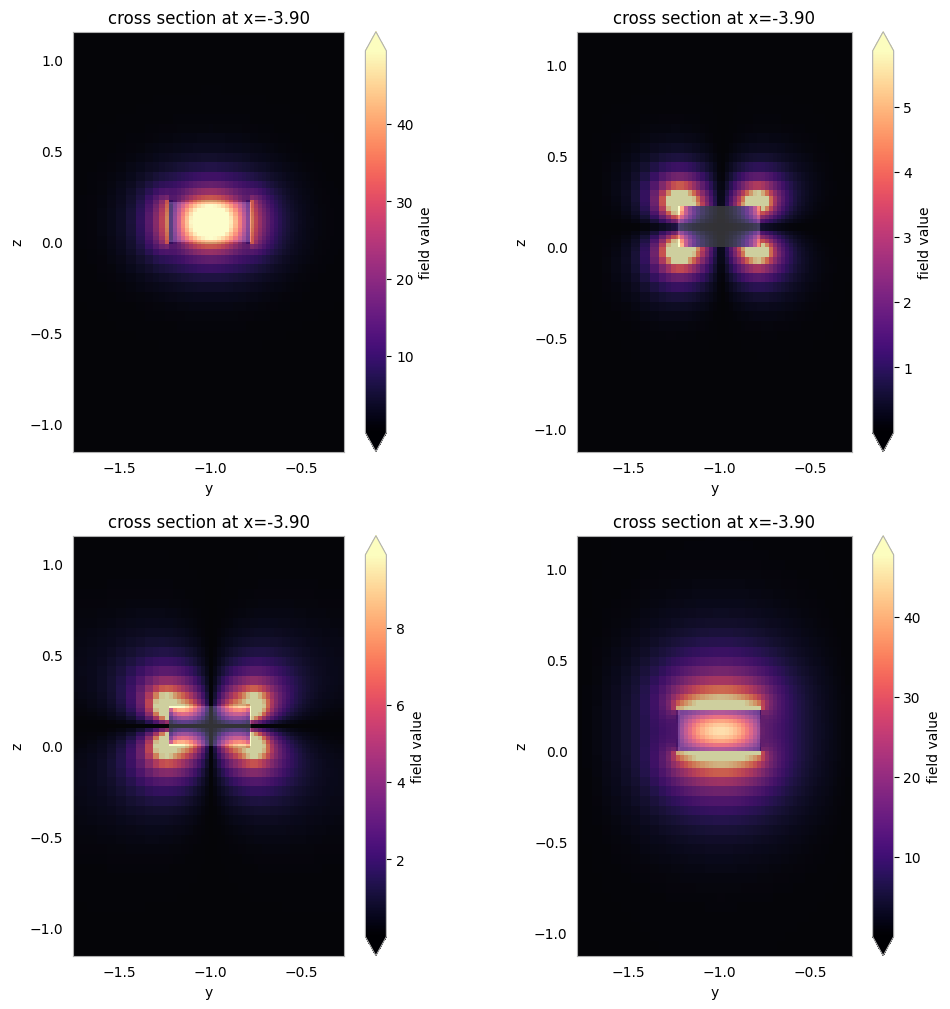

<Axes: title={'center': 'cross section at x=0.00'}, xlabel='y', ylabel='z'>

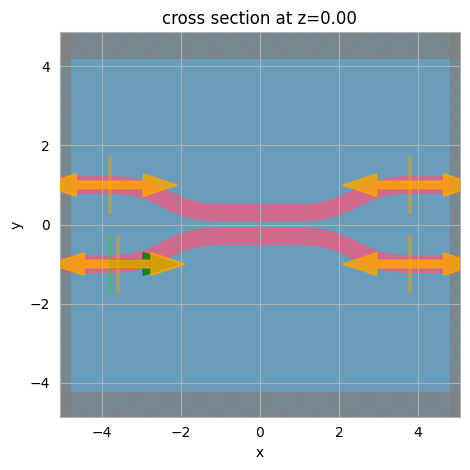

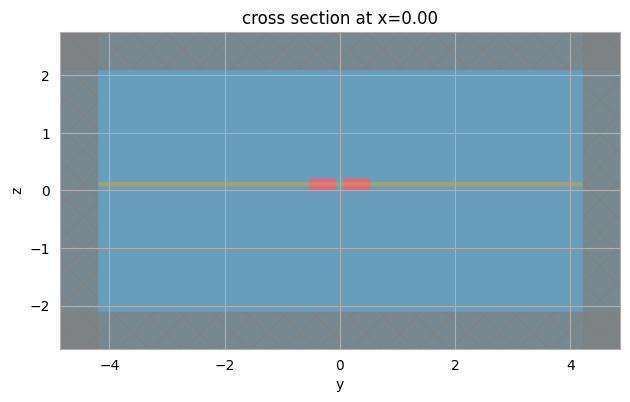

In [6]:
coupler = coupler_symmetric(gap, 2.0, separation=separation, bend_factor=bend_factor, cross_section=cross_section)

sim_specs = dict(
    layer_stack=layer_stack,
    wavelength_start=wavelengths[0],
    wavelength_stop=wavelengths[-1],
    wavelength_points=wavelengths.size,
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=20),
)

simulation = gt.get_simulation(
    coupler,
    ymargin=2.0,
    num_modes=2,
    plot_modes=True,
    with_all_monitors=True,
    **sim_specs,
)

simulation.plot(z=0)
simulation.plot(x=0)

Because of the smooth S bend regions, the usual analytical models to calulate the power ratio of the DC give only a rough estimate.  We sweep a range of DC lengths based on those estimates to find the dimensions required in our design for the given PDK.

2023-02-21 21:42:14.046 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_53f03236_a5cd92f8.npz')
2023-02-21 21:42:14.094 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_7105b3d6_a5cd92f8.npz')
2023-02-21 21:42:14.099 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_8dac97f5_a5cd92f8.npz')
2023-02-21 21:42:14.110 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_63991586_a5cd92f8.npz')
2023-02-21 21:42:14.118 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/luc

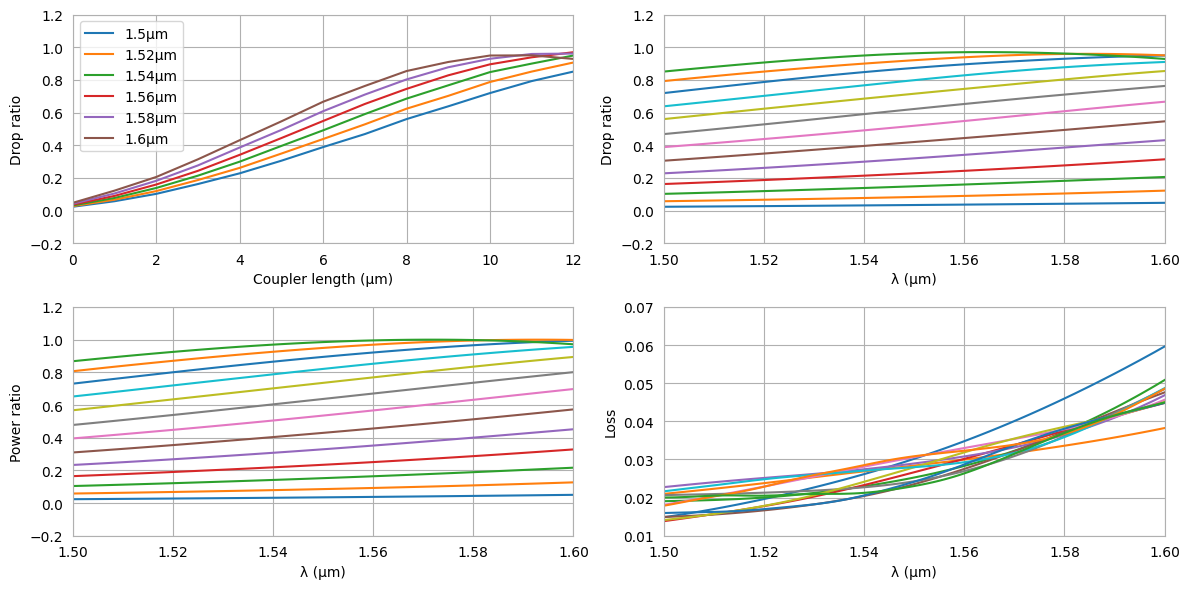

In [7]:
sim_lengths = np.linspace(0.0, 12.0, 13)
s_params_list = [
    gt.write_sparameters(
        component=coupler_symmetric(
            gap, length, separation=separation, bend_factor=bend_factor, cross_section=cross_section
        ),
        ymargin=2.0,
        num_modes=2,
        port_source_names=["o1"],
        **sim_specs,
    ) for length in sim_lengths
]

wavelengths = s_params_list[0]["wavelengths"]
drop = np.array([np.abs(s["o3@0,o1@0"]) ** 2 for s in s_params_list])
thru = np.array([np.abs(s["o4@0,o1@0"]) ** 2 for s in s_params_list])
loss = 1 - (drop + thru)
sim_ratios = drop / (drop + thru)

fig, ax = plt.subplots(2, 2, figsize=(12, 6))

for i in range(0, wavelengths.size, 20):
    ax[0, 0].plot(sim_lengths, drop[:, i], label=f"{wavelengths[i]}µm")

for i, length in enumerate(sim_lengths):
    ax[0, 1].plot(wavelengths, drop[i, :], label=f"{length}µm")
    ax[1, 0].plot(wavelengths, sim_ratios[i, :], label=f"{length}µm")
    ax[1, 1].plot(wavelengths, loss[i, :], label=f"{length}µm")

ax[0, 0].set_xlabel("Coupler length (µm)")
ax[0, 0].set_ylabel("Drop ratio")
ax[0, 1].set_xlabel("λ (µm)")
ax[0, 1].set_ylabel("Drop ratio")
ax[1, 0].set_xlabel("λ (µm)")
ax[1, 0].set_ylabel("Power ratio")
ax[1, 1].set_xlabel("λ (µm)")
ax[1, 1].set_ylabel("Loss")
ax[0, 0].legend()
fig.tight_layout()

Now we crete a fitting function to calculate the DC length for a given power ratio.

In the filter specification, the desired ratios are 0.5, 0.13, 0.12, 0.5, and 0.25.  We calculate the DC lengths accordingly.

In [8]:
def coupler_length(λ: float = 1.55, power_ratio: float = 0.5):
    i0 = np.argmin(np.abs(wavelengths - λ))
    i1 = min(i0 + 1, len(wavelengths) - 1) if λ > wavelengths[i] else max(i0 - 1, 0)
    if i1 != i0:
        pr = (sim_ratios[:, i0] * (wavelengths[i1] - λ) + sim_ratios[:, i1] * (λ - wavelengths[i0])) / (wavelengths[i1] - wavelengths[i0])
    else:
        pr = sim_ratios[:, i0]
    y = pr - power_ratio
    root_indices = np.flatnonzero(y[1:] * y[:-1] <= 0)
    if len(root_indices) == 0:
        return sim_lengths[np.argmin(np.abs(y))]
    j = root_indices[0]
    return (sim_lengths[j] * (pr[j + 1] - power_ratio) + sim_lengths[j + 1] * (power_ratio - pr[j])) / (pr[j + 1] - pr[j])

power_ratios = [0.50, 0.13, 0.12, 0.50, 0.25]
lengths = [coupler_length(lda_c, pr) for pr in power_ratios]
print("Power ratios:", power_ratios)
print("Lengths:", lengths)

Power ratios: [0.5, 0.13, 0.12, 0.5, 0.25]
Lengths: [5.664796037386495, 1.6658935787103828, 1.5164966876624808, 5.664796037386495, 3.1666186391472024]


Finally, we simulate the DCs with the calculated lengths to guarantee the fitting error is within tolerance.  As expected, all DCs have the correct power ratios at the central wavelength.

2023-02-21 21:42:15.703 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_140ef54c_a5cd92f8.npz')
2023-02-21 21:42:15.727 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_8210dad0_a5cd92f8.npz')
2023-02-21 21:42:15.751 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_f6812405_a5cd92f8.npz')
2023-02-21 21:42:15.764 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_140ef54c_a5cd92f8.npz')
2023-02-21 21:42:15.784 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/luc

[-0.000249813980855329, -0.003020663008654473, -0.0035053869849440145, -0.000249813980855329, -0.0011161388236601566]


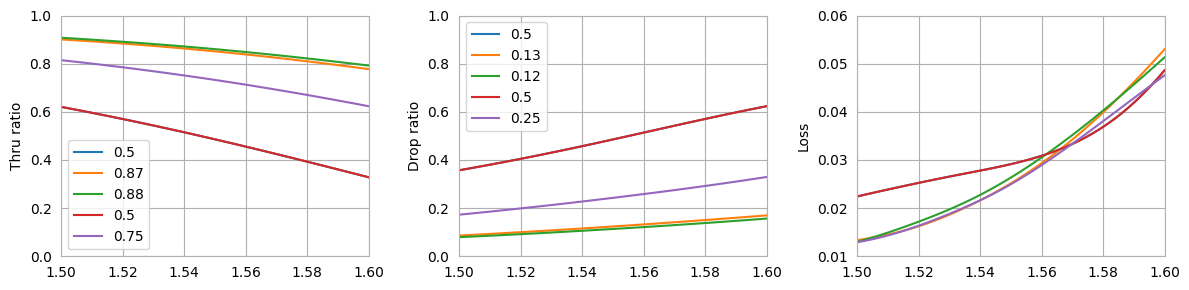

In [9]:
s_params_list = [
    gt.write_sparameters(
        component=coupler_symmetric(
            gap, length, separation=separation, bend_factor=bend_factor, cross_section=cross_section
        ),
        ymargin=2.0,
        num_modes=2,
        port_source_names=["o1"],
        port_symmetries={
            "o1@0,o1@0": {"o2@0,o2@0", "o3@0,o3@0", "o4@0,o4@0"},
            "o2@0,o1@0": {"o1@0,o2@0", "o4@0,o3@0", "o3@0,o4@0"},
            "o3@0,o1@0": {"o1@0,o3@0", "o4@0,o2@0", "o2@0,o4@0"},
            "o4@0,o1@0": {"o1@0,o4@0", "o3@0,o2@0", "o2@0,o3@0"},
        },
        **sim_specs,
    ) for length in lengths
]

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
errors = []
i = wavelengths.size // 2

for pr, sp in zip(power_ratios, s_params_list):
    drop = np.abs(sp["o3@0,o1@0"]) ** 2
    thru = np.abs(sp["o4@0,o1@0"]) ** 2
    
    assert lda_c == wavelengths[i]
    errors.append(drop[i] / (thru[i] + drop[i]) - pr)

    ax[0].plot(wavelengths, thru, label=f"{1 - pr}")
    ax[1].plot(wavelengths, drop, label=f"{pr}")
    ax[2].plot(wavelengths, 1 - thru - drop)

ax[0].set_ylabel("Thru ratio")
ax[1].set_ylabel("Drop ratio")
ax[2].set_ylabel("Loss")
ax[0].set_ylim(0, 1)
ax[1].set_ylim(0, 1)
ax[0].legend()
ax[1].legend()
fig.tight_layout()

print(errors)

Now we have to design the arms of each MZI.  The most important parameter here is their free spectral range (FSR), which comes from the path lenght diference and the group index of the waveguide at the central wavelength:

$$\text{FSR} = \frac{\lambda_c^2}{n_g \Delta L}$$

We calculate the group indes for our waveguides through `tidy3d`'s local mode solver.  Because we're interested in precise dispersion, we use a dense mesh and high precision in these calculations.

The path lenght differences for the MZIs are $\Delta L$,  $2\Delta L$, $L_\pi - 2\Delta L$, and $-2\Delta L$, with $L_\pi$ the length required for $\pi$ phase shift (negative values indicate a delay in the opposite arm to positive values).

2023-02-21 21:42:17.051 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/099230f9.npz mode data from file cache.


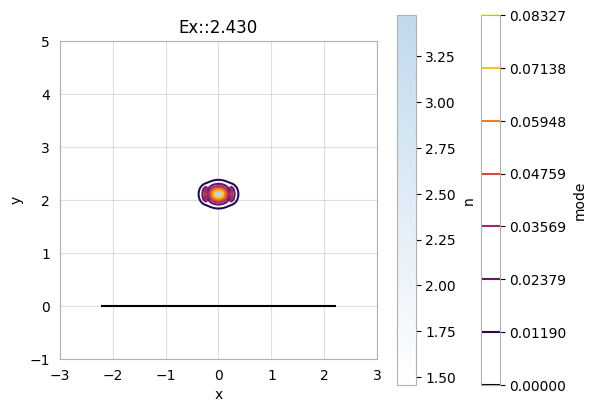

2023-02-21 21:42:17.585 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/27acb37d.npz mode data from file cache.
2023-02-21 21:42:17.617 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/ef6aa5c8.npz mode data from file cache.


ne = 2.4296986916776357, ng = 4.272638545345849
Path difference (ΔL = 56.22989107321106, Lπ = 0.31896959184880874): [56.22989107321106, 112.45978214642211, -112.1408125545733, -112.45978214642211]


In [10]:
def group_index(waveguide: gt.modes.Waveguide, mode: int = 0, wavelength_delta: float = 0.01):
    arg_dict = waveguide.dict()
    kwargs = {k: arg_dict[k] for k in waveguide.settings}
    kwargs["wavelength"] = waveguide.wavelength - wavelength_delta
    w0 = gt.modes.Waveguide(**kwargs)
    kwargs["wavelength"] = waveguide.wavelength + wavelength_delta
    w2 = gt.modes.Waveguide(**kwargs)
    waveguide.compute_modes()
    n1 = waveguide.neffs.flat[mode].real
    w0.compute_modes()
    n0 = w0.neffs.flat[mode].real
    w2.compute_modes()
    n2 = w2.neffs.flat[mode].real
    return n1 - waveguide.wavelength * (n2 - n0) / (2 * wavelength_delta)


def mzi_path_difference(waveguide: gt.modes.Waveguide, group_index: float, fsr: float):
    return waveguide.wavelength ** 2 / (fsr * group_index)


mode_solver_specs = dict(
    wg_width=width,
    wg_thickness=core.thickness,
    slab_thickness=0,
    ncore=core.material,
    nclad=clad.material,
    nmodes=2,
    xmargin=2.0,
    t_box=min(2.0, box.thickness),
    t_clad=min(2.0, clad.thickness),
    resolution=200,
    precision="double",
)

waveguide_solver = gt.modes.Waveguide(wavelength=lda_c, **mode_solver_specs)
waveguide_solver.plot_Ex(mode_index=0, plot_power=False)

ng = group_index(waveguide_solver)
ne = waveguide_solver.neffs.flat[0].real
print(f"ne = {ne}, ng = {ng}")

length_delta = mzi_path_difference(waveguide_solver, ng, fsr)
length_pi = lda_c / (2 * ne)
mzi_deltas = [length_delta, 2 * length_delta, length_pi - 2 * length_delta, -2 * length_delta]
print(f"Path difference (ΔL = {length_delta}, Lπ = {length_pi}):", mzi_deltas)

Next we create a helper function that returns the MZI arms for a given length difference, respecting the bend radius defined in our PDK.

In [11]:
def mzi_arms(mzi_delta: float, separation: float = 4.0, cross_section: gf.types.CrossSectionSpec = "strip") -> gf.Component:
    bend = gf.components.bend_euler(cross_section=cross_section)
    
    if mzi_delta > 0:
        arm0 = [
            gf.ComponentReference(bend),
            gf.ComponentReference(gf.components.straight(mzi_delta / 2, cross_section=cross_section)),
            gf.ComponentReference(bend).mirror(),
            gf.ComponentReference(gf.components.straight(separation * 2, cross_section=cross_section)),
            gf.ComponentReference(bend).mirror(),
            gf.ComponentReference(gf.components.straight(mzi_delta / 2, cross_section=cross_section)),
            gf.ComponentReference(bend),
        ]
        arm1 = [
            gf.ComponentReference(gf.components.straight(separation, cross_section=cross_section)),
            gf.ComponentReference(bend),
            gf.ComponentReference(bend).mirror(),
            gf.ComponentReference(bend).mirror(),
            gf.ComponentReference(bend),
            gf.ComponentReference(gf.components.straight(separation, cross_section=cross_section)),
        ]
    else:
        arm0 = [
            gf.ComponentReference(gf.components.straight(separation, cross_section=cross_section)),
            gf.ComponentReference(bend).mirror(),
            gf.ComponentReference(bend),
            gf.ComponentReference(bend),
            gf.ComponentReference(bend).mirror(),
            gf.ComponentReference(gf.components.straight(separation, cross_section=cross_section)),
        ]
        arm1 = [
            gf.ComponentReference(bend).mirror((0, 0), (1, 0)),
            gf.ComponentReference(gf.components.straight(-mzi_delta / 2, cross_section=cross_section)),
            gf.ComponentReference(bend),
            gf.ComponentReference(gf.components.straight(separation * 2, cross_section=cross_section)),
            gf.ComponentReference(bend),
            gf.ComponentReference(gf.components.straight(-mzi_delta / 2, cross_section=cross_section)),
            gf.ComponentReference(bend).mirror(),
        ]
    
    return (arm0, arm1)


mzi_arms(mzi_deltas[0], separation=separation, cross_section=cross_section)

/home/lucas/Flexcompute/dev/gdsfactory/gdsfactory/__init__.py:83: UserWarning: gdsfactory.types has been renamed to gdsfactory.typings
  warn("gdsfactory.types has been renamed to gdsfactory.typings")


([ComponentReference (parent Component "bend_euler_9f1d144f", ports ['o1', 'o2'], origin (0.0, 0.0), rotation 0.0, x_reflection False),
  ComponentReference (parent Component "straight_f57aca0b", ports ['o1', 'o2'], origin (0.0, 0.0), rotation 0.0, x_reflection False),
  ComponentReference (parent Component "bend_euler_9f1d144f", ports ['o1', 'o2'], origin (1.2246467991473532e-16, 0.0), rotation 180.0, x_reflection True),
  ComponentReference (parent Component "straight_5980b58d", ports ['o1', 'o2'], origin (0.0, 0.0), rotation 0.0, x_reflection False),
  ComponentReference (parent Component "bend_euler_9f1d144f", ports ['o1', 'o2'], origin (1.2246467991473532e-16, 0.0), rotation 180.0, x_reflection True),
  ComponentReference (parent Component "straight_f57aca0b", ports ['o1', 'o2'], origin (0.0, 0.0), rotation 0.0, x_reflection False),
  ComponentReference (parent Component "bend_euler_9f1d144f", ports ['o1', 'o2'], origin (0.0, 0.0), rotation 0.0, x_reflection False)],
 [ComponentRe

Now we can put all pieces together to layout the complete cascaded MZI filter:

In [12]:
@gf.cell
def cascaded_mzi(coupler_gaps, coupler_lengths, mzi_deltas, separation: float = 4.0, bend_factor: float = 3.0, cross_section: gf.types.CrossSectionSpec = "strip") -> gf.Component:
    assert len(coupler_lengths) > 0
    assert len(coupler_gaps) == len(coupler_lengths)
    assert len(mzi_deltas) + 1 == len(coupler_lengths)
    c = gf.Component()
    
    coupler = c.add_ref(coupler_symmetric(coupler_gaps[0], coupler_lengths[0], separation=separation, bend_factor=bend_factor, cross_section=cross_section))
    c.add_port(name="o1", port=coupler.ports["o1"])
    c.add_port(name="o2", port=coupler.ports["o2"])

    for g, l, dl in zip(coupler_gaps[1:], coupler_lengths[1:], mzi_deltas):
        arm0, arm1 = mzi_arms(dl, separation=separation, cross_section=cross_section)
        c.add(arm0)
        c.add(arm1)
        arm0[0].connect("o1", coupler.ports["o3"])
        arm1[0].connect("o1", coupler.ports["o4"])
        for arm in (arm0, arm1):
            for r0, r1 in zip(arm[:-1], arm[1:]):
                r1.connect("o1", r0.ports["o2"])
        coupler = c.add_ref(coupler_symmetric(g, l, separation=separation, bend_factor=bend_factor, cross_section=cross_section))
        coupler.connect("o1", arm1[-1].ports["o2"])

    c.add_port(name="o3", port=coupler.ports["o3"])
    c.add_port(name="o4", port=coupler.ports["o4"])

    return c


layout = cascaded_mzi(coupler_gaps=[gap] * len(lengths), coupler_lengths=lengths, mzi_deltas=mzi_deltas, separation=separation, bend_factor=bend_factor, cross_section=cross_section)
layout

AppLayout(children=(Tab(children=(VBox(children=(HBox(children=(Button(layout=Layout(border_bottom='solid 2px …

cascaded_mzi_0a29c5a8: uid 3c663cba, ports ['o1', 'o2', 'o3', 'o4'], references ['coupler_symmetric_1', 'bend_euler_1', 'straight_1', 'bend_euler_2', 'straight_2', 'bend_euler_3', 'straight_3', 'bend_euler_4', 'straight_4', 'bend_euler_5', 'bend_euler_6', 'bend_euler_7', 'bend_euler_8', 'straight_5', 'coupler_symmetric_2', 'bend_euler_9', 'straight_6', 'bend_euler_10', 'straight_7', 'bend_euler_11', 'straight_8', 'bend_euler_12', 'straight_9', 'bend_euler_13', 'bend_euler_14', 'bend_euler_15', 'bend_euler_16', 'straight_10', 'coupler_symmetric_3', 'straight_11', 'bend_euler_17', 'bend_euler_18', 'bend_euler_19', 'bend_euler_20', 'straight_12', 'bend_euler_21', 'straight_13', 'bend_euler_22', 'straight_14', 'bend_euler_23', 'straight_15', 'bend_euler_24', 'coupler_symmetric_4', 'straight_16', 'bend_euler_25', 'bend_euler_26', 'bend_euler_27', 'bend_euler_28', 'straight_17', 'bend_euler_29', 'straight_18', 'bend_euler_30', 'straight_19', 'bend_euler_31', 'straight_20', 'bend_euler_32', '

Finally, we want to build a complete simulation of the filter based on individual models for its components.

We extract the filter netlist and verify we'll need models for the straight and bend sections, as well as for the DCs.

In [13]:
netlist = layout.get_netlist()
set(v["component"] for v in netlist["instances"].values())

{'bend_euler', 'coupler_symmetric', 'straight'}

The model for the straight sections is based directly on the waveguide mode, including dispersion effects.

[21:42:18] INFO     Unable to initialize backend 'tpu_driver': NOT_FOUND: Unable to find driver   ]8;id=345933;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py\xla_bridge.py]8;;\:]8;id=19131;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py#421\421]8;;\
                    in registry given worker:                                                                      

           INFO     Unable to initialize backend 'cuda': module 'jaxlib.xla_extension' has no     ]8;id=801236;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py\xla_bridge.py]8;;\:]8;id=573734;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py#421\421]8;;\
                    attribute 'GpuAllocatorConfig'                                                                 

           INFO     Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no     ]8;id=293106;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py\xla_bridge.py]8;;\:]8;id=61082;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py#421\421]8;;\
                    attribute 'GpuAllocatorConfig'                                                                 

           INFO     Unable to initialize backend 'tpu': INVALID_ARGUMENT: TpuPlatform is not      ]8;id=828526;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py\xla_bridge.py]8;;\:]8;id=229809;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py#421\421]8;;\
                    available.                                                                                     

           INFO     Unable to initialize backend 'plugin': xla_extension has no attributes named  ]8;id=181625;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py\xla_bridge.py]8;;\:]8;id=135870;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py#421\421]8;;\
                    get_plugin_device_client. Compile TensorFlow with                                              
                    //tensorflow/compiler/xla/python:enable_plugin_device set to true (defaults                    
                    to false) to enable this.                                                                      

           WARNING  No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun  ]8;id=601956;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py\xla_bridge.py]8;;\:]8;id=944307;file:///home/lucas/.venv/flexcompute/lib/python3.10/site-packages/jax/_src/lib/xla_bridge.py#428\428]8;;\
                    for more info.)                                                                                

2023-02-21 21:42:18.664 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/113ddefa.npz mode data from file cache.
2023-02-21 21:42:18.705 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/9d82a5be.npz mode data from file cache.
2023-02-21 21:42:18.747 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/bc04afc6.npz mode data from file cache.
2023-02-21 21:42:18.788 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/5a0c0a9d.npz mode data from file cache.
2023-02-21 21:42:18.830 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/141b3157.npz mode data from file cache.
2023-02-21 21:42:18.872 | INFO     | gdsfactory.simulation.gtidy3d.modes:compute_modes:439 - load /home/lucas/.gdsfactory/modes/b1fc9d7f.npz mode data from file

Text(0, 0.5, 'n_eff')

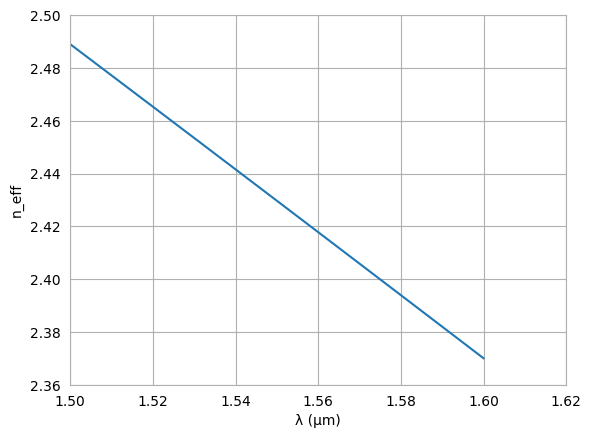

In [14]:
straight_wavelengths = jnp.linspace(wavelengths[0], wavelengths[-1], 11)
straight_neffs = np.empty(straight_wavelengths.size, dtype=complex)

for i in range(straight_wavelengths.size):
    waveguide_solver = gt.modes.Waveguide(wavelength=straight_wavelengths[i], **mode_solver_specs)
    waveguide_solver.compute_modes()
    straight_neffs[i] = waveguide_solver.neffs[0]

plt.plot(straight_wavelengths, straight_neffs.real)
plt.xlabel("λ (µm)")
plt.ylabel("n_eff")

In [15]:
@jax.jit
def straight_model(wl=1.55, length: float = 1.0):
    s21 = jnp.exp(2j * jnp.pi * jnp.interp(wl, straight_wavelengths, straight_neffs) * length / wl)
    zero = jnp.zeros_like(wl)
    return {
        ("o1", "o1"): zero,
        ("o1", "o2"): s21,
        ("o2", "o1"): s21,
        ("o2", "o2"): zero,
    }


straight_model()

{('o1', 'o1'): Array(0., dtype=float32, weak_type=True),
 ('o1', 'o2'): Array(-0.91127914-0.41178918j, dtype=complex64),
 ('o2', 'o1'): Array(-0.91127914-0.41178918j, dtype=complex64),
 ('o2', 'o2'): Array(0., dtype=float32, weak_type=True)}

For the bends, we want to include the full S matrix, because we are not using a circular shape, so simple modal decomposition becomes less accurate.  Similarly, we want to use the full simulated S matrix from the DCs in our model, instead of analytical approximations.

We encapsulate the S parameter calculation in a helper function that generates the `jax` model for each component.

In [16]:
def bend_model(cross_section: gf.types.CrossSectionSpec = "strip"):
    s = gt.write_sparameters(
        component=gf.components.bend_euler(cross_section=cross_section),
        num_modes=2,
        port_source_names=["o1"],
        **sim_specs,
    )
    wavelengths = s.pop("wavelengths")
    
    @jax.jit
    def _model(wl=1.55):
        s11 = jnp.interp(wl, wavelengths, s["o1@0,o1@0"])
        s21 = jnp.interp(wl, wavelengths, s["o2@0,o1@0"])
        return {
            ('o1', 'o1'): s11,
            ('o1', 'o2'): s21,
            ('o2', 'o1'): s21,
            ('o2', 'o2'): s11,
        }
    return _model


bend_model(cross_section=cross_section)()

2023-02-21 21:42:19.744 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/bend_euler_9f1d144f_d434fc51.npz')


{('o1', 'o1'): Array(0.00802973-0.00473539j, dtype=complex64),
 ('o1', 'o2'): Array(-0.9822558+0.1859176j, dtype=complex64),
 ('o2', 'o1'): Array(-0.9822558+0.1859176j, dtype=complex64),
 ('o2', 'o2'): Array(0.00802973-0.00473539j, dtype=complex64)}

2023-02-21 21:42:19.975 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/bend_euler_9f1d144f_d434fc51.npz')


Text(0.5, 0, 'λ (µm)')

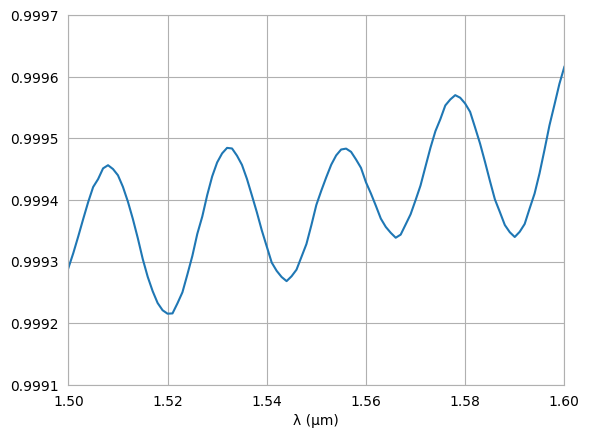

In [17]:
c = gf.Component(name="bend")
ref = c.add_ref(gf.components.bend_euler(cross_section=cross_section))
c.add_ports(ref.ports)
x, _ = sax.circuit(c.get_netlist(), {"bend_euler": bend_model(cross_section=cross_section)})

s = x(wl=wavelengths)
plt.plot(wavelengths, jnp.abs(s[("o1", "o2")]) ** 2)
plt.xlabel("λ (µm)")

In [18]:
def coupler_model(gap: float = 0.1, length: float = 1.0, separation: float = 4.0, bend_factor: float = 3.0, cross_section: gf.types.CrossSectionSpec = "strip"):
    s = gt.write_sparameters(
        component=coupler_symmetric(gap, length, separation=separation, bend_factor=bend_factor, cross_section=cross_section),
        ymargin=2.0,
        num_modes=2,
        port_source_names=["o1"],
        **sim_specs,
    )
    wavelengths = s.pop("wavelengths")
    
    @jax.jit
    def _model(wl=1.55):
        s11 = jnp.interp(wl, wavelengths, s["o1@0,o1@0"])
        s21 = jnp.interp(wl, wavelengths, s["o2@0,o1@0"])
        s31 = jnp.interp(wl, wavelengths, s["o3@0,o1@0"])
        s41 = jnp.interp(wl, wavelengths, s["o4@0,o1@0"])
        return {
            ('o1', 'o1'): s11,
            ('o1', 'o2'): s21,
            ('o1', 'o3'): s31,
            ('o1', 'o4'): s41,
            ('o2', 'o1'): s21,
            ('o2', 'o2'): s11,
            ('o2', 'o3'): s41,
            ('o2', 'o4'): s31,
            ('o3', 'o1'): s31,
            ('o3', 'o2'): s41,
            ('o3', 'o3'): s11,
            ('o3', 'o4'): s21,
            ('o4', 'o1'): s41,
            ('o4', 'o2'): s31,
            ('o4', 'o3'): s21,
            ('o4', 'o4'): s11,
        }
    return _model


coupler_model(gap, lengths[0], separation=separation, bend_factor=bend_factor, cross_section=cross_section)()

2023-02-21 21:42:20.950 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_140ef54c_a5cd92f8.npz')


{('o1', 'o1'): Array(-0.00505368-0.00229945j, dtype=complex64),
 ('o1', 'o2'): Array(4.4898145e-05+0.00547472j, dtype=complex64),
 ('o1', 'o3'): Array(-0.68258446+0.13881414j, dtype=complex64),
 ('o1', 'o4'): Array(0.13931453+0.6828378j, dtype=complex64),
 ('o2', 'o1'): Array(4.4898145e-05+0.00547472j, dtype=complex64),
 ('o2', 'o2'): Array(-0.00505368-0.00229945j, dtype=complex64),
 ('o2', 'o3'): Array(0.13931453+0.6828378j, dtype=complex64),
 ('o2', 'o4'): Array(-0.68258446+0.13881414j, dtype=complex64),
 ('o3', 'o1'): Array(-0.68258446+0.13881414j, dtype=complex64),
 ('o3', 'o2'): Array(0.13931453+0.6828378j, dtype=complex64),
 ('o3', 'o3'): Array(-0.00505368-0.00229945j, dtype=complex64),
 ('o3', 'o4'): Array(4.4898145e-05+0.00547472j, dtype=complex64),
 ('o4', 'o1'): Array(0.13931453+0.6828378j, dtype=complex64),
 ('o4', 'o2'): Array(-0.68258446+0.13881414j, dtype=complex64),
 ('o4', 'o3'): Array(4.4898145e-05+0.00547472j, dtype=complex64),
 ('o4', 'o4'): Array(-0.00505368-0.00229

We must take care of using one model for each DC based on its length, so we use another helper function that iterates over the netlist instances and generates the appropriate model for each one:

2023-02-21 21:42:21.327 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_1710794e_a5cd92f8.npz')
2023-02-21 21:42:21.696 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_ecd761e3_a5cd92f8.npz')
2023-02-21 21:42:22.064 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_2a4193ff_a5cd92f8.npz')
2023-02-21 21:42:22.430 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_5e39768e_a5cd92f8.npz')


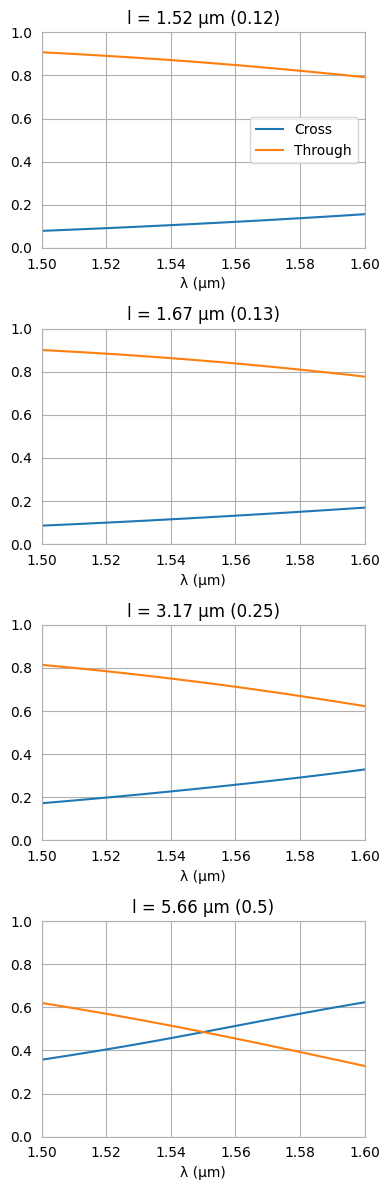

In [19]:
def patch_netlist(netlist, models, models_to_patch):
    instances = netlist["instances"]
    for name in instances:
        model = instances[name]
        if model["component"] in models_to_patch:
            component = model["component"]
            i = 0
            new_component = f"{component}_v{i}"
            while new_component in models:
                i += 1
                new_component = f"{component}_v{i}"
            models[new_component] = models_to_patch[model["component"]](**model["settings"])
            del model["settings"]
            model["component"] = new_component 
    return netlist, models


pl_set = sorted(set((pr, l) for pr, l in zip(power_ratios, lengths)))
fig, ax = plt.subplots(len(pl_set), 1, figsize=(4, 3 * len(pl_set)))

for i, (pr, l) in enumerate(pl_set):
    c = gf.Component(name="single mzi 2")
    ref = c.add_ref(coupler_symmetric(gap, l, separation=separation, bend_factor=bend_factor, cross_section=cross_section))
    c.add_ports(ref.ports)
    netlist, models = patch_netlist(c.get_netlist(), {}, {"coupler_symmetric": coupler_model})
    x, _ = sax.circuit(netlist, models)

    s = x(wl=wavelengths)
    ax[i].plot(wavelengths, jnp.abs(s[("o1", "o3")]) ** 2, label="Cross")
    ax[i].plot(wavelengths, jnp.abs(s[("o1", "o4")]) ** 2, label="Through")
    ax[i].set_ylim(0, 1)
    ax[i].set_xlabel("λ (µm)")
    ax[i].set_title(f"l = {l:.2f} µm ({pr})")

ax[0].legend()
fig.tight_layout()

Finally, we can simulate the complete filter response around the central wavelength and get the desired FSR and box-like shape.

2023-02-21 21:42:24.136 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/bend_euler_9f1d144f_d434fc51.npz')
2023-02-21 21:42:24.141 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_5e39768e_a5cd92f8.npz')
2023-02-21 21:42:24.146 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_ecd761e3_a5cd92f8.npz')
2023-02-21 21:42:24.152 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gdsfactory/sp/coupler_symmetric_1710794e_a5cd92f8.npz')
2023-02-21 21:42:24.158 | INFO     | gdsfactory.simulation.gtidy3d.write_sparameters:write_sparameters:163 - Simulation loaded from PosixPath('/home/lucas/.gds

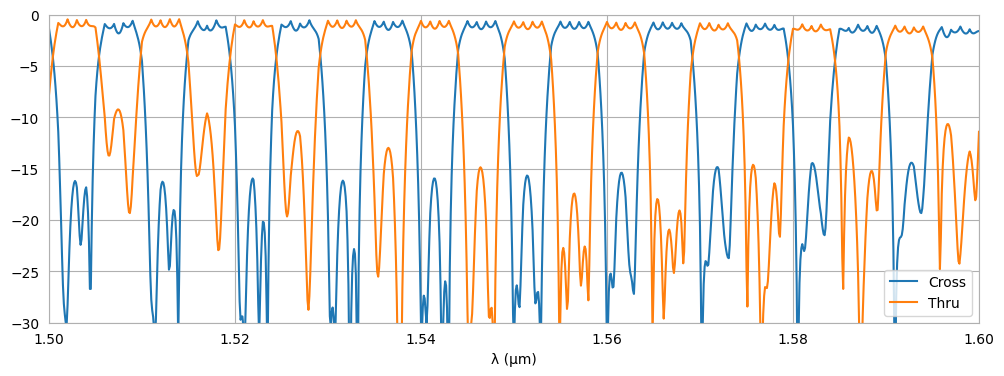

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

layout = cascaded_mzi(coupler_gaps=[gap] * len(lengths), coupler_lengths=lengths, mzi_deltas=mzi_deltas, separation=separation, bend_factor=bend_factor, cross_section=cross_section)
netlist, models = patch_netlist(layout.get_netlist(), {"straight": straight_model, "bend_euler": bend_model(cross_section=cross_section)}, {"coupler_symmetric": coupler_model})
circuit, _ = sax.circuit(netlist, models)

lda = np.linspace(1.5, 1.6, 1001)
s = circuit(wl=lda)
ax.plot(lda, 20 * jnp.log10(jnp.abs(s[("o1", "o3")])), label="Cross")
ax.plot(lda, 20 * jnp.log10(jnp.abs(s[("o1", "o4")])), label="Thru")
ax.set_ylim(-30, 0)
ax.set_xlabel("λ (µm)")
ax.legend()